# NeuralMag cube-tower relaxation from a MuMax setup

This notebook mirrors the MuMax geometry you shared: six 168 nm cubes, 3 nm cells, 3 nm cube-to-cube spacing offsets, exchange + demag + cubic anisotropy, and an optional MuMax OVF seed.

The main outputs are:
- a relaxed NeuralMag state,
- cell-centred magnetisation arrays,
- per-cube mean magnetisation vectors and moments,
- quick slice and quiver plots for inspection.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import neuralmag as nm
except ImportError as exc:
    raise ImportError(
        "This notebook requires the NeuralMag Python package in the current kernel. "
        "The repo notes suggest using the .venv-notebook environment."
    ) from exc

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=4, suppress=True)

2026-04-27 11:52:55 NeuralMag:INFO [NeuralMag] Version 0.9.4


In [2]:
# MuMax-like problem setup
D_nm = 168.0
s_nm = 3.0
cellsize_nm = 3.0

nx = int(2 * D_nm / cellsize_nm)
ny = int((6 * D_nm + 6 * s_nm) / cellsize_nm)
nz = int(D_nm / cellsize_nm)

Msat_A_per_m = 480e3
Aex_J_per_m = 1e-11
alpha = 0.1
Kc1_J_per_m3 = -1.35e4

anisotropy_configs = {
    "0, 0, 1 Axis": (
        np.array([0.0, 0.0, 1.0], dtype=np.float32),
        np.array([0.0, 1.0, 0.0], dtype=np.float32),
    ),
    "1, 1, 1 Axis": (
        np.array([1.0, 1.0, 1.0], dtype=np.float32),
        np.array([1.0, -1.0, 0.0], dtype=np.float32),
    ),
}
reference_anisotropy_name = next(iter(anisotropy_configs))

L_nm = D_nm / 2.0
cube_centers_y_nm = {
    "cube1": (5 * L_nm) + (2 * s_nm),
    "cube2": (3 * L_nm) + (1 * s_nm),
    "cube3": (1 * L_nm) + (0 * s_nm),
    "cube4": -((1 * L_nm) + (1 * s_nm)),
    "cube5": -((3 * L_nm) + (2 * s_nm)),
    "cube6": -((5 * L_nm) + (3 * s_nm)),
}

# Point this to your MuMax seed if you want to start from m.LoadFile(...)
ovf_path = Path("vortex_cube_128_00+1.ovf")
init_mode = "ovf_if_available"  # "ovf_if_available", "uniform_y", "random"

llg_max_steps = 300
llg_tol_1_per_s = 5e8
llg_dt_s = 3e-12
demag_p = 3

cwd = Path.cwd().resolve()
repo_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), cwd)
output_dir = repo_root / "notebooks/MBIR/neuralmag_cube_tower_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Grid: nx={nx}, ny={ny}, nz={nz}")
print(f"Cell size: {cellsize_nm} nm")
print(f"OVF seed exists: {ovf_path.exists()} -> {ovf_path}")
print(f"Anisotropy variants: {', '.join(anisotropy_configs)}")
print(f"Reference anisotropy for plot labels: {reference_anisotropy_name}")
print(f"Output dir: {output_dir}")

Grid: nx=112, ny=342, nz=56
Cell size: 3.0 nm
OVF seed exists: False -> vortex_cube_128_00+1.ovf
Anisotropy variants: 0, 0, 1 Axis, 1, 1, 1 Axis
Reference anisotropy for plot labels: 0, 0, 1 Axis
Output dir: /Users/landers/LiberTEM-holo/notebooks/MBIR/neuralmag_cube_tower_outputs


In [4]:
def cell_centered_axes(nx: int, ny: int, nz: int, cellsize_nm: float):
    x = (np.arange(nx, dtype=np.float32) + 0.5) * cellsize_nm - (nx * cellsize_nm / 2.0)
    y = (np.arange(ny, dtype=np.float32) + 0.5) * cellsize_nm - (ny * cellsize_nm / 2.0)
    z = (np.arange(nz, dtype=np.float32) + 0.5) * cellsize_nm - (nz * cellsize_nm / 2.0)
    return np.meshgrid(x, y, z, indexing="ij")


def make_cube_tower_support(nx: int, ny: int, nz: int, cellsize_nm: float, cube_size_nm: float, centers_y_nm: dict[str, float]):
    xx, yy, zz = cell_centered_axes(nx, ny, nz, cellsize_nm)
    half = cube_size_nm / 2.0
    rho = np.zeros((nx, ny, nz), dtype=np.float32)
    masks = {}
    for name, cy in centers_y_nm.items():
        mask = (
            (np.abs(xx) <= half)
            & (np.abs(yy - cy) <= half)
            & (np.abs(zz) <= half)
        )
        masks[name] = mask
        rho[mask] = 1.0
    return rho, masks


def _parse_ovf_header(header_text: str):
    meta = {}
    begin_line = None
    for raw_line in header_text.splitlines():
        line = raw_line.strip()
        if not line.startswith("#"):
            continue
        content = line[1:].strip()
        if content.lower().startswith("begin: data"):
            begin_line = content
        if ":" in content:
            key, value = content.split(":", 1)
            meta[key.strip().lower()] = value.strip()
    if begin_line is None:
        raise ValueError("Could not find '# Begin: Data ...' in OVF header.")
    return meta, begin_line.lower()


def load_mumax_ovf(path: str | Path, expected_shape: tuple[int, int, int] | None = None):
    path = Path(path)
    raw = path.read_bytes()
    marker = b"# Begin: Data"
    idx = raw.find(marker)
    if idx < 0:
        raise ValueError(f"Could not find OVF data block in {path}.")
    header_end = raw.find(b"\n", idx)
    if header_end < 0:
        raise ValueError(f"Malformed OVF header in {path}.")
    header = raw[: header_end + 1].decode("utf-8", errors="replace")
    meta, begin_line = _parse_ovf_header(header)

    xnodes = int(meta["xnodes"])
    ynodes = int(meta["ynodes"])
    znodes = int(meta["znodes"])
    valuedim = int(meta.get("valuedim", "3"))
    if valuedim != 3:
        raise ValueError(f"Expected valuedim=3, got {valuedim}.")

    data_start = header_end + 1
    count = xnodes * ynodes * znodes * valuedim
    if "binary 4" in begin_line:
        data_start += 4
        values = np.frombuffer(raw, dtype="<f4", offset=data_start, count=count)
    elif "binary 8" in begin_line:
        data_start += 8
        values = np.frombuffer(raw, dtype="<f8", offset=data_start, count=count)
    elif "text" in begin_line:
        data_text = raw[data_start:].decode("utf-8", errors="replace")
        data_text = data_text.split("# End: Data", 1)[0]
        values = np.fromstring(data_text, sep=" ", dtype=np.float32)
        values = values[:count]
    else:
        raise ValueError(f"Unsupported OVF data block: {begin_line}")

    if values.size != count:
        raise ValueError(f"Expected {count} values in {path}, got {values.size}.")

    # OVF data are written with x fastest, then y, then z. Reshape to x,y,z,3.
    field_zyx = values.reshape((znodes, ynodes, xnodes, valuedim))
    field_xyz = np.transpose(field_zyx, (2, 1, 0, 3)).astype(np.float32)
    if expected_shape is not None and field_xyz.shape[:3] != expected_shape:
        raise ValueError(
            f"OVF shape {field_xyz.shape[:3]} does not match expected {expected_shape}."
        )
    return field_xyz, meta


def normalize_on_support(m_cell: np.ndarray, rho_cell: np.ndarray, threshold: float = 0.5):
    m = np.asarray(m_cell, dtype=np.float32)
    rho = np.asarray(rho_cell, dtype=np.float32)
    norms = np.linalg.norm(m, axis=-1, keepdims=True)
    safe_norms = np.where(norms > 0.0, norms, 1.0)
    m_norm = m / safe_norms
    support = rho[..., None] > threshold
    return np.where(support, m_norm, 0.0).astype(np.float32)


def orthonormalize_anisotropy_axes(axis1: np.ndarray, axis2: np.ndarray):
    axis1 = np.asarray(axis1, dtype=np.float32)
    axis2 = np.asarray(axis2, dtype=np.float32)

    axis1 /= np.linalg.norm(axis1)
    axis2 = axis2 - np.dot(axis2, axis1) * axis1
    axis2 /= np.linalg.norm(axis2)
    axis3 = np.cross(axis1, axis2).astype(np.float32)
    axis3 /= np.linalg.norm(axis3)
    return axis1.astype(np.float32), axis2.astype(np.float32), axis3


def cell_vectors_to_normalized_node_function(state, m_cell: np.ndarray, rho_cell: np.ndarray):
    rho_cf = nm.CellFunction(state, tensor=state.tensor(rho_cell.astype(np.float32)))
    m_cf = nm.VectorCellFunction(state, tensor=state.tensor(m_cell.astype(np.float32)))
    rho_node = np.asarray(rho_cf.to_node().tensor)
    m_node = np.asarray(m_cf.to_node().tensor)
    norms = np.linalg.norm(m_node, axis=-1, keepdims=True)
    safe_norms = np.where(norms > 0.0, norms, 1.0)
    m_node = m_node / safe_norms
    m_node = np.where(rho_node[..., None] > 0.5, m_node, 0.0).astype(np.float32)
    return nm.VectorFunction(state, tensor=state.tensor(m_node))


def make_initial_m_cell(rho_cell: np.ndarray, init_mode: str, ovf_path: Path | None = None, rng_seed: int = 0):
    shape = rho_cell.shape + (3,)
    if init_mode == "ovf_if_available" and ovf_path is not None and ovf_path.exists():
        m_cell, ovf_meta = load_mumax_ovf(ovf_path, expected_shape=rho_cell.shape)
        print(f"Loaded OVF seed from {ovf_path}")
        print({k: ovf_meta[k] for k in ("xnodes", "ynodes", "znodes") if k in ovf_meta})
        return normalize_on_support(m_cell, rho_cell)
    if init_mode == "random":
        rng = np.random.default_rng(rng_seed)
        m_cell = rng.normal(size=shape).astype(np.float32)
        return normalize_on_support(m_cell, rho_cell)
    m_cell = np.zeros(shape, dtype=np.float32)
    m_cell[..., 1] = 1.0
    return normalize_on_support(m_cell, rho_cell)


def build_neuralmag_state(
    rho_cell: np.ndarray,
    m0_cell: np.ndarray,
    anis_axis1: np.ndarray,
    anis_axis2: np.ndarray,
    anis_label: str,
):
    state = nm.State(nm.Mesh((nx, ny, nz), (cellsize_nm * 1e-9,) * 3))
    rho_min = float(getattr(state, "eps", 1e-12))
    rho_safe = np.clip(rho_cell.astype(np.float32), rho_min, 1.0)
    state.rho = nm.CellFunction(state, tensor=state.tensor(rho_safe))

    state.material.Ms = nm.CellFunction(state).fill(Msat_A_per_m)
    state.material.A = nm.CellFunction(state).fill(Aex_J_per_m)
    state.material.alpha = nm.CellFunction(state).fill(alpha)
    state.material.Kc = nm.CellFunction(state).fill(Kc1_J_per_m3)

    axis1_vec, axis2_vec, axis3_vec = orthonormalize_anisotropy_axes(anis_axis1, anis_axis2)
    axis1 = np.zeros((nx, ny, nz, 3), dtype=np.float32)
    axis2 = np.zeros((nx, ny, nz, 3), dtype=np.float32)
    axis3 = np.zeros((nx, ny, nz, 3), dtype=np.float32)
    axis1[...] = axis1_vec
    axis2[...] = axis2_vec
    axis3[...] = axis3_vec

    state.material.Kc_axis1 = nm.VectorCellFunction(state, tensor=state.tensor(axis1))
    state.material.Kc_axis2 = nm.VectorCellFunction(state, tensor=state.tensor(axis2))
    state.material.Kc_axis3 = nm.VectorCellFunction(state, tensor=state.tensor(axis3))
    state.m = cell_vectors_to_normalized_node_function(state, m0_cell, rho_cell)
    state.anisotropy_label = anis_label

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.CubicAnisotropyField().register(state, "cubic")
    nm.TotalField("exchange", "demag", "cubic").register(state)
    return state


def relax_state_with_llg(state, *, max_steps: int, tol: float, dt: float):
    llg = nm.LLGSolver(state, max_steps=max_steps)
    llg.relax(tol=tol, dt=dt)
    return state, llg


def summarize_cube_magnetization(m_cell: np.ndarray, cube_masks: dict[str, np.ndarray], cellsize_nm: float, Msat_A_per_m: float):
    cell_volume_m3 = (cellsize_nm * 1e-9) ** 3
    rows = []
    for name, mask in cube_masks.items():
        voxels = int(mask.sum())
        m_mean = m_cell[mask].mean(axis=0)
        volume_m3 = voxels * cell_volume_m3
        moment_Am2 = Msat_A_per_m * volume_m3 * m_mean
        rows.append({
            "cube": name,
            "voxels": voxels,
            "volume_m3": volume_m3,
            "mean_mx": float(m_mean[0]),
            "mean_my": float(m_mean[1]),
            "mean_mz": float(m_mean[2]),
            "mean_m_norm": float(np.linalg.norm(m_mean)),
            "moment_x_Am2": float(moment_Am2[0]),
            "moment_y_Am2": float(moment_Am2[1]),
            "moment_z_Am2": float(moment_Am2[2]),
        })
    return rows

In [4]:
rho_cell, cube_masks = make_cube_tower_support(
    nx=nx,
    ny=ny,
    nz=nz,
    cellsize_nm=cellsize_nm,
    cube_size_nm=D_nm,
    centers_y_nm=cube_centers_y_nm,
)

m0_cell = make_initial_m_cell(rho_cell, init_mode=init_mode, ovf_path=ovf_path)

print(f"Support voxels: {int(rho_cell.sum())}")
print(f"Support fraction: {rho_cell.mean():.4f}")
print(f"Initial |m| on support: {np.linalg.norm(m0_cell[rho_cell > 0.5], axis=-1).mean():.4f}")


Support voxels: 1053696
Support fraction: 0.4912
Initial |m| on support: 1.0000


In [5]:
results = {}
summary_rows = []

for anisotropy_name, (axis1, axis2) in anisotropy_configs.items():
    print(f"Running relaxation for {anisotropy_name}...")
    state = build_neuralmag_state(
        rho_cell=rho_cell,
        m0_cell=m0_cell,
        anis_axis1=axis1,
        anis_axis2=axis2,
        anis_label=anisotropy_name,
    )
    state, llg = relax_state_with_llg(
        state,
        max_steps=llg_max_steps,
        tol=llg_tol_1_per_s,
        dt=llg_dt_s,
    )

    m_relaxed_cell = np.asarray(state.m.to_cell().tensor)
    rho_relaxed_cell = np.asarray(state.rho.tensor)

    summary = summarize_cube_magnetization(
        m_cell=m_relaxed_cell,
        cube_masks=cube_masks,
        cellsize_nm=cellsize_nm,
        Msat_A_per_m=Msat_A_per_m,
    )
    annotated_rows = [
        {**row, "anisotropy": anisotropy_name}
        for row in summary
    ]
    summary_rows.extend(annotated_rows)

    results[anisotropy_name] = {
        "state": state,
        "llg": llg,
        "rho": rho_relaxed_cell,
        "m": m_relaxed_cell,
        "summary_rows": annotated_rows,
    }

if pd is not None:
    summary_comparison = pd.DataFrame(summary_rows)
else:
    summary_comparison = summary_rows

summary_comparison

2026-04-24 20:36:42 NeuralMag:INFO [Mesh] 3D, 112 x 342 x 56 (size = 3e-09 x 3e-09 x 3e-09)


Running relaxation for 0, 0, 1 Axis...


2026-04-24 20:36:43 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-24 20:36:43 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-24 20:36:43 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2026-04-24 20:36:52 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-24 20:36:52 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-24 20:36:52 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-24 20:36:52 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-24 20:36:57 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-24 20:36:57 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-24 20:36:57 NeuralMag:INFO [LLGSolverJAX] Init

Running relaxation for 1, 1, 1 Axis...


2026-04-24 20:39:34 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-24 20:39:34 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-24 20:39:34 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-24 20:39:36 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-24 20:39:36 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-24 20:39:36 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-04-24 20:39:39 NeuralMag:INFO [LLGSolverJAX] Relaxation started, initial energy E = 4.69079e-16 J
2026-04-24 20:40:30 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 4.74136e+10) 1/s
2026-04-24 20:41:21 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 3.40073e+10) 1/s
2026-04-24 20:

[{'cube': 'cube1',
  'voxels': 175616,
  'volume_m3': 4.741632000000001e-21,
  'mean_mx': -2.2116280362638463e-08,
  'mean_my': 0.6185434460639954,
  'mean_mz': 1.8575303784018615e-07,
  'mean_m_norm': 0.6185434460639954,
  'moment_x_Am2': -5.0336289817171844e-23,
  'moment_y_Am2': 1.4077946987206568e-15,
  'moment_z_Am2': 4.227708296777608e-22,
  'anisotropy': '0, 0, 1 Axis'},
 {'cube': 'cube2',
  'voxels': 175616,
  'volume_m3': 4.741632000000001e-21,
  'mean_mx': -1.8598621309706687e-08,
  'mean_my': 0.9988982677459717,
  'mean_mz': -1.9286590380307445e-10,
  'mean_m_norm': 0.9988982677459717,
  'moment_x_Am2': -4.233015311185828e-23,
  'moment_y_Am2': 2.2734760292208262e-15,
  'moment_z_Am2': -4.389596292541624e-25,
  'anisotropy': '0, 0, 1 Axis'},
 {'cube': 'cube3',
  'voxels': 175616,
  'volume_m3': 4.741632000000001e-21,
  'mean_mx': 2.1146520090553622e-09,
  'mean_my': 0.9999347925186157,
  'mean_mz': -4.335452552517438e-10,
  'mean_m_norm': 0.9999347925186157,
  'moment_x_Am2'

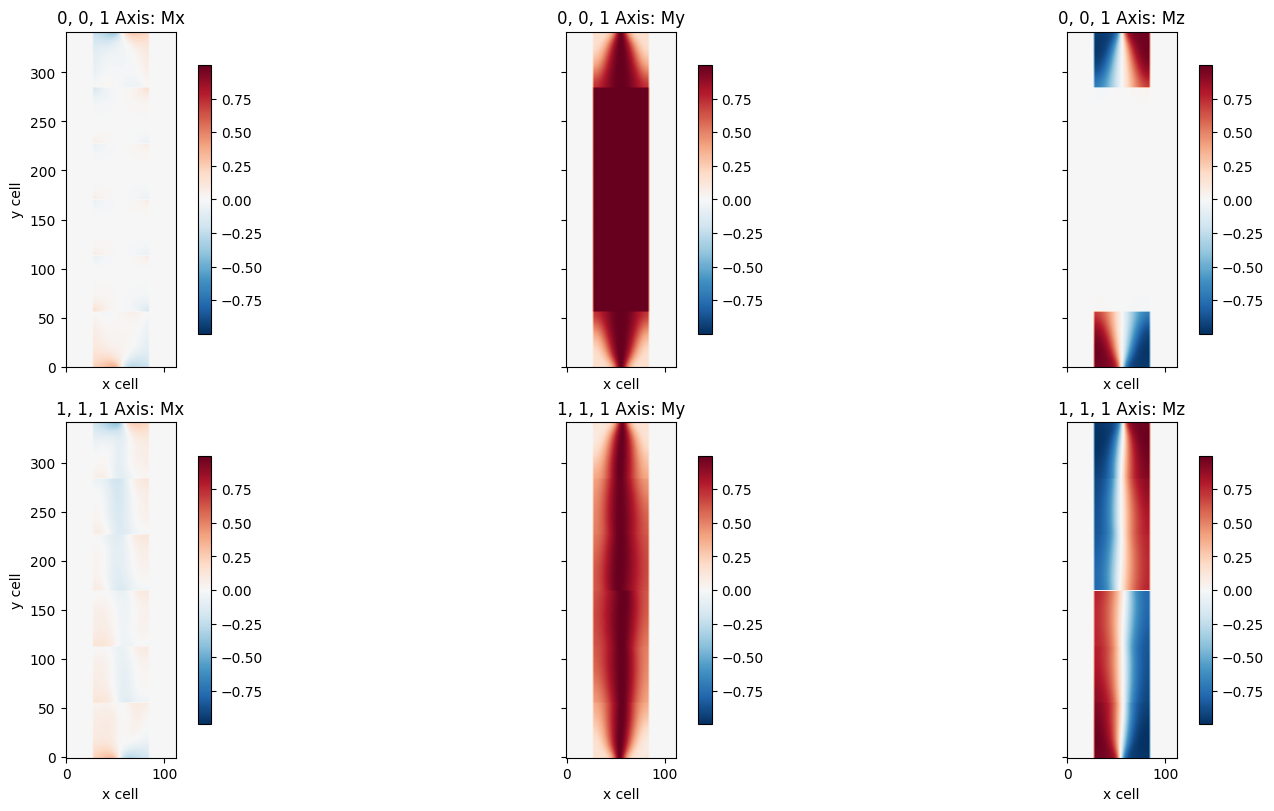

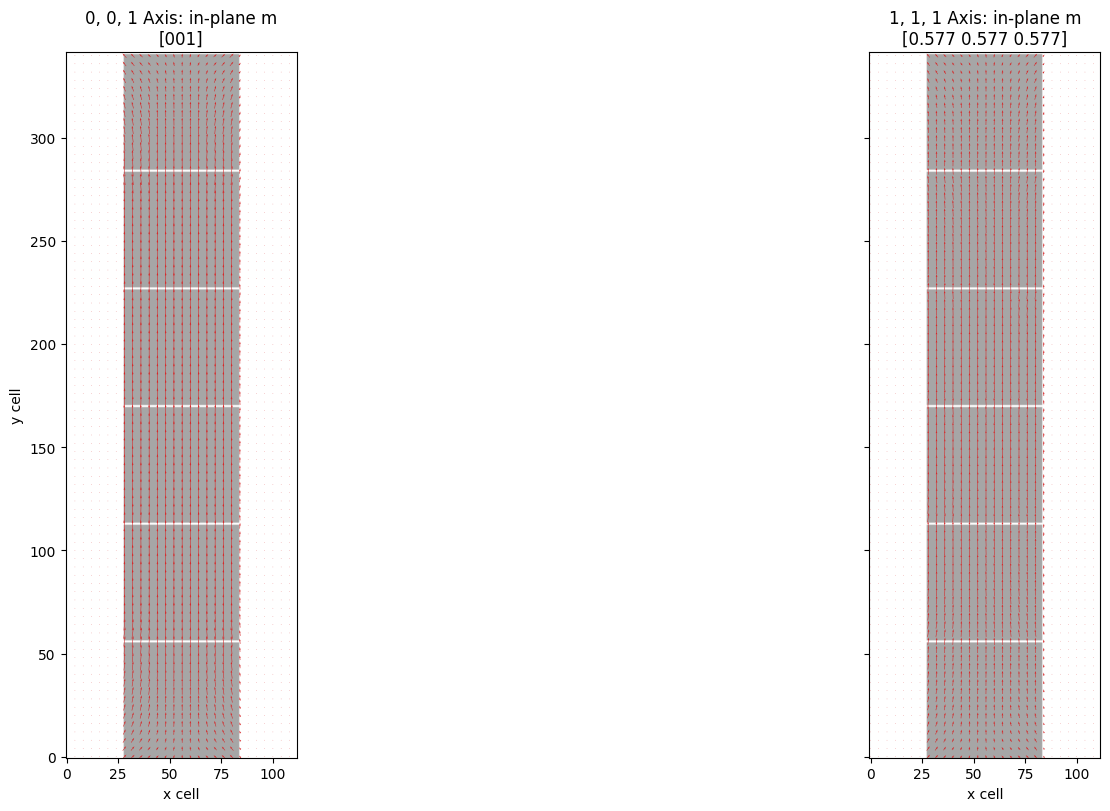

In [6]:
def canonicalize_axis_direction(axis: np.ndarray) -> np.ndarray:
    axis = np.asarray(axis, dtype=np.float32)
    for value in axis:
        if np.isclose(value, 0.0):
            continue
        if value < 0:
            return -axis
        return axis
    return axis


def format_crystallographic_axis(axis: np.ndarray) -> str:
    axis = np.asarray(axis, dtype=np.float32)
    rounded = np.rint(axis).astype(int)
    if np.allclose(axis, rounded, atol=1e-6) and np.any(rounded != 0):
        components = []
        for value in rounded:
            if value < 0:
                components.append(f"{abs(value)}bar")
            else:
                components.append(str(value))
        return "[" + "".join(components) + "]"
    return np.array2string(axis, precision=3, suppress_small=True)


z_mid = nz // 2
anisotropy_names = list(results)
component_labels = ["Mx", "My", "Mz"]
component_vmax = max(float(np.abs(result["m"]).max()) for result in results.values())
orientation_labels = {}

# Extract raw (unnormalized) axis labels directly from anisotropy_configs
for anisotropy_name in anisotropy_names:
    axis1, axis2 = anisotropy_configs[anisotropy_name]
    # Use raw axis1 without orthonormalization
    orientation_labels[anisotropy_name] = format_crystallographic_axis(axis1)

fig, axs = plt.subplots(
    len(anisotropy_names),
    3,
    figsize=(15, 4 * len(anisotropy_names)),
    constrained_layout=True,
    squeeze=False,
    sharex=True,
    sharey=True,
)
for row, anisotropy_name in enumerate(anisotropy_names):
    m_relaxed_cell = results[anisotropy_name]["m"]
    for col, component_label in enumerate(component_labels):
        ax = axs[row, col]
        im = ax.imshow(
            m_relaxed_cell[:, :, z_mid, col].T,
            cmap="RdBu_r",
            vmin=-component_vmax,
            vmax=component_vmax,
        )
        ax.set_title(f"{anisotropy_name}: {component_label}")
        ax.set_xlabel("x cell")
        if col == 0:
            ax.set_ylabel("y cell")
        plt.colorbar(im, ax=ax, shrink=0.8)
plt.show()

fig, axs = plt.subplots(
    1,
    len(anisotropy_names),
    figsize=(8 * len(anisotropy_names), 8),
    constrained_layout=True,
    squeeze=False,
    sharex=True,
    sharey=True,
 )
for col, anisotropy_name in enumerate(anisotropy_names):
    ax = axs[0, col]
    m_relaxed_cell = results[anisotropy_name]["m"]
    rho_relaxed_cell = results[anisotropy_name]["rho"]
    orientation_label = orientation_labels[anisotropy_name]
    m_xy_mean = m_relaxed_cell.mean(axis=2)
    step = 4
    xg, yg = np.meshgrid(np.arange(nx), np.arange(ny), indexing="ij")
    ax.imshow(rho_relaxed_cell.mean(axis=2).T, cmap="gray_r", alpha=0.35)
    ax.quiver(
        xg[::step, ::step].T,
        yg[::step, ::step].T,
        m_xy_mean[::step, ::step, 0].T,
        m_xy_mean[::step, ::step, 1].T,
        pivot="mid",
        color="tab:red",
        scale=20,
    )
    ax.set_title(f"{anisotropy_name}: in-plane m\n{orientation_label}")
    ax.set_xlabel("x cell")
    if col == 0:
        ax.set_ylabel("y cell")
plt.show()

In [7]:
# Optional exports for downstream inspection.
export_payload = {
    "cellsize_nm": np.float32(cellsize_nm),
    "anisotropy_names": np.array(list(results.keys()), dtype=object),
}
for anisotropy_name, result in results.items():
    export_key = anisotropy_name.lower().replace(" ", "_")
    export_payload[f"rho_{export_key}"] = result["rho"].astype(np.float32)
    export_payload[f"m_{export_key}"] = result["m"].astype(np.float32)

export_payload["summary"] = np.asarray(summary_rows, dtype=object)

np.savez_compressed(output_dir / "cube_tower_relaxed_comparison.npz", **export_payload)

anisotropy_names_for_export = list(results)
state_for_export = results[anisotropy_names_for_export[0]]["state"]
if hasattr(state_for_export, "write_vti"):
    state_for_export.write_vti(["rho", "m"], str(output_dir / "cube_tower_relaxed_reference.vti"))

print(f"Saved comparison results under: {output_dir}")

Saved comparison results under: /Users/landers/LiberTEM-holo/notebooks/MBIR/neuralmag_cube_tower_outputs


## Notes

- If your MuMax OVF is not on exactly the same grid as this notebook, update `ovf_path` and the geometry block together.
- The notebook now runs the same cube-tower initial state against each entry in `anisotropy_configs` and compares the relaxed states side by side.
- Alternate anisotropy axes are orthonormalized before being assigned to `Kc_axis1..3`, so non-unit input vectors are safe to compare.
- The notebook uses `LLGSolver(...).relax(...)`, matching the repo's current NeuralMag usage pattern.
- If you want the initial state to match the MuMax script exactly, set `ovf_path` to the same `.ovf` used by `m.LoadFile(...)`.
- The per-cube table reports the mean normalised magnetisation vector and the magnetic moment estimate `Ms * volume * mean(m)`.


## Vmapped steepest-descent orientation fit

This reset keeps only a simple objective: load one exported cube-tower target, compare against its projected ground-truth phase, and run the same differentiable relaxation from 8 symmetry-related `<111>` starts in parallel.

The inner equilibrium solve still uses the shared differentiable BB2/Cayley relaxation from `libertem_holo.base.mbir.equilibrium_orientation_fit`, but the outer axis update is now plain steepest descent instead of the previous notebook-level validation and per-start loop machinery.

The section below does only four things:
- picks one explicit ground-truth target from the exported NPZ,
- defines the 8 `<111>` start directions,
- runs one vmapped steepest-descent fit over all 8 starts,
- compares the best fitted phase directly to the projected ground-truth phase.

In [3]:
import sys
import time

import jax
import jax.numpy as jnp
import numpy as np

if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))
if str(repo_root / "vendor/neuralmag") not in sys.path:
    sys.path.insert(0, str(repo_root / "vendor/neuralmag"))

from libertem_holo.base.mbir.equilibrium_orientation_fit import (
    EquilibriumOrientationFitConfig,
    angle_params_to_anisotropy_axes,
    angular_distance_deg,
    build_equilibrium_orientation_problem,
    ensure_neuralmag_jax_backend,
    make_vmapped_steepest_descent_multi_start,
    phase_from_relaxed_m,
    phase_loss_after_relax,
    prepare_equilibrium_fit_target_from_npz,
    unit_vector_to_axis_angles,
)

nm = ensure_neuralmag_jax_backend()

try:
    backend_name = nm.config.backend.name
except AttributeError:
    backend_name = getattr(nm.config, "backend_name", None)

print(f"NeuralMag backend for orientation fit: {backend_name}")

E0427 11:53:11.354489 1235595 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 106.88GiB (114756157440 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0427 11:53:15.358595 1235595 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 96.19GiB (103280541696 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0427 11:53:19.344579 1235595 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 86.57GiB (92952485888 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0427 11:53:23.340563 1235595 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 77.91GiB (83657236480 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0427 11:53:27.352395 1235595 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 70.12GiB (75291508736

NeuralMag backend for orientation fit: jax


In [4]:
fit_target_name = "1, 1, 1 Axis"
differentiable_fit_npz = output_dir / "cube_tower_relaxed_comparison.npz"

equilibrium_fit_config = EquilibriumOrientationFitConfig(
    coarse_grain_factor=4,
    support_threshold=0.5,
    demag_p=2,
    phase_pad=16,
    minimizer_tol=1e3,
    minimizer_relative_tol=1e-2,
    minimizer_min_iter=16,
    minimizer_stall_patience=64,
    minimizer_stall_relative_improvement=1e-4,
    minimizer_max_iter=96,
    outer_steps=12,
    axis_learning_rate=6e-2,
)

fit_random_m_seed = 11
fit_normalize_gradients = True


def _format_axis_label(axis: np.ndarray) -> str:
    axis = np.asarray(axis, dtype=np.float32)
    rounded = np.rint(axis).astype(int)
    if np.allclose(axis, rounded, atol=1e-6) and np.any(rounded != 0):
        parts = []
        for value in rounded:
            if value < 0:
                parts.append(f"{abs(value)}bar")
            else:
                parts.append(str(value))
        return "[" + "".join(parts) + "]"
    return np.array2string(axis, precision=3, suppress_small=True)


_s = 1.0 / np.sqrt(3.0)
initial_axes_111 = np.array(
    [
        [+_s, +_s, +_s],
        [+_s, +_s, -_s],
        [+_s, -_s, +_s],
        [+_s, -_s, -_s],
        [-_s, +_s, +_s],
        [-_s, +_s, -_s],
        [-_s, -_s, +_s],
        [-_s, -_s, -_s],
    ],
    dtype=np.float32,
)
initial_axis_labels = [f"start {_format_axis_label(np.rint(axis * np.sqrt(3.0)).astype(np.int32))}" for axis in initial_axes_111]

print({
    "fit_target_name": fit_target_name,
    "coarse_grain_factor": equilibrium_fit_config.coarse_grain_factor,
    "demag_p": equilibrium_fit_config.demag_p,
    "minimizer_max_iter": equilibrium_fit_config.minimizer_max_iter,
    "outer_steps": equilibrium_fit_config.outer_steps,
    "axis_learning_rate": equilibrium_fit_config.axis_learning_rate,
    "normalize_gradients": fit_normalize_gradients,
    "n_starts": len(initial_axes_111),
})

{'fit_target_name': '1, 1, 1 Axis', 'coarse_grain_factor': 4, 'demag_p': 2, 'minimizer_max_iter': 96, 'outer_steps': 12, 'axis_learning_rate': 0.06, 'normalize_gradients': True, 'n_starts': 8}


In [5]:
if not differentiable_fit_npz.exists():
    raise FileNotFoundError(
        f"Missing {differentiable_fit_npz}. Run the relaxation/export cells above first."
    )

target = prepare_equilibrium_fit_target_from_npz(
    differentiable_fit_npz,
    fit_target_name,
    config=equilibrium_fit_config,
)
problem = build_equilibrium_orientation_problem(
    target,
    Msat_A_per_m=Msat_A_per_m,
    Aex_J_per_m=Aex_J_per_m,
    Kc1_J_per_m3=Kc1_J_per_m3,
    config=equilibrium_fit_config,
)

ground_truth_axis = np.asarray(anisotropy_configs[fit_target_name][0], dtype=np.float32)
ground_truth_axis /= np.linalg.norm(ground_truth_axis)

ground_truth_phase = np.asarray(target.phase_target, dtype=np.float32)
direct_phase = np.asarray(
    phase_from_relaxed_m(problem, jnp.asarray(target.m_xyz, dtype=jnp.float32)),
    dtype=np.float32,
)
direct_phase_residual = direct_phase - ground_truth_phase
direct_phase_loss = float(0.5 * np.mean(direct_phase_residual * direct_phase_residual))
direct_phase_rms = float(np.sqrt(np.mean(direct_phase_residual * direct_phase_residual)))

rng_m = np.random.default_rng(fit_random_m_seed)
m0_shared = rng_m.normal(size=problem.target.m_xyz.shape).astype(np.float32)

init_angles_batch = jnp.asarray(
    [unit_vector_to_axis_angles(axis) for axis in initial_axes_111],
    dtype=jnp.float32,
)
axis2_hint = jnp.asarray(problem.config.axis2_hint, dtype=jnp.float32)

run_all_starts = make_vmapped_steepest_descent_multi_start(
    problem,
    m0_shared,
    learning_rate=equilibrium_fit_config.axis_learning_rate,
    outer_steps=equilibrium_fit_config.outer_steps,
    normalize_gradients=fit_normalize_gradients,
)

started = time.perf_counter()
final_angles, final_losses, final_rms, loss_history, rms_history, axis1_history = run_all_starts(
    init_angles_batch
)
_ = final_losses.block_until_ready()
elapsed_s = time.perf_counter() - started

final_axis1_batch = np.asarray(
    jax.vmap(
        lambda angles: angle_params_to_anisotropy_axes(angles, axis2_hint=axis2_hint)[0]
    )(final_angles),
    dtype=np.float32,
)
final_losses_np = np.asarray(final_losses, dtype=np.float32)
final_rms_np = np.asarray(final_rms, dtype=np.float32)
loss_history_np = np.asarray(loss_history, dtype=np.float32)
rms_history_np = np.asarray(rms_history, dtype=np.float32)

best_idx = int(np.argmin(final_losses_np))
best_angles = final_angles[best_idx]
best_axis1 = final_axis1_batch[best_idx]
best_loss, best_aux = phase_loss_after_relax(problem, best_angles, np.asarray(m0_shared, dtype=np.float32))

phase_target = ground_truth_phase
phase_pred = np.asarray(best_aux["phase_pred"], dtype=np.float32)
phase_residual = phase_pred - phase_target

fit_summary_rows = []
for idx, start_label in enumerate(initial_axis_labels):
    fit_summary_rows.append(
        {
            "start": start_label,
            "start_axis": np.array2string(initial_axes_111[idx], precision=3, suppress_small=True),
            "final_axis": np.array2string(final_axis1_batch[idx], precision=3, suppress_small=True),
            "final_loss": float(final_losses_np[idx]),
            "final_phase_rms": float(final_rms_np[idx]),
            "start_angle_to_truth_deg": angular_distance_deg(initial_axes_111[idx], ground_truth_axis),
            "final_angle_to_truth_deg": angular_distance_deg(final_axis1_batch[idx], ground_truth_axis),
        }
    )
fit_summary = pd.DataFrame(fit_summary_rows) if pd is not None else fit_summary_rows

best_result = {
    "start": initial_axis_labels[best_idx],
    "axis1": best_axis1,
    "loss": float(np.asarray(best_loss)),
    "phase_rms": float(np.asarray(best_aux["phase_rms"])),
    "n_iter": int(np.asarray(best_aux["n_iter"])),
    "max_g": float(np.asarray(best_aux["max_g"])),
    "converged": bool(np.asarray(best_aux["converged"])),
    "max_iter_limited": bool(np.asarray(best_aux["max_iter_limited"])),
}

print("Selected ground-truth target")
print("-" * 80)
print(
    f"Target: {fit_target_name} | rho_xyz={target.rho_xyz.shape} | "
    f"cell={target.cellsize_nm:g} nm | phase={tuple(target.phase_target.shape)}"
)
print(
    f"Direct projection check: loss={direct_phase_loss:.6g}, rms={direct_phase_rms:.6g}"
)
print(
    f"Vmapped steepest descent: {len(initial_axes_111)} starts in {elapsed_s:.2f}s | "
    f"outer_steps={equilibrium_fit_config.outer_steps} | lr={equilibrium_fit_config.axis_learning_rate:.4g}"
)
print(
    f"Best start: {best_result['start']} | loss={best_result['loss']:.6g} | "
    f"phase_rms={best_result['phase_rms']:.6g} | final_axis={best_result['axis1']}"
)

/Users/landers/neuralmag/.venv-notebook/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:140: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  coeff_val = jnp.asarray(coeff.value, dtype=dtype)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:160: UserWarning: Explicitly re

Selected ground-truth target
--------------------------------------------------------------------------------
Target: 1, 1, 1 Axis | rho_xyz=(28, 85, 14) | cell=12 nm | phase=(117, 60)
Direct projection check: loss=0, rms=0
Vmapped steepest descent: 8 starts in 90.70s | outer_steps=12 | lr=0.06
Best start: start [11bar1bar] | loss=33.6552 | phase_rms=8.20429 | final_axis=[ 0.5504 -0.7424 -0.3821]


In [6]:
if pd is not None:
    fit_summary_display = fit_summary.sort_values("final_loss").reset_index(drop=True)
else:
    fit_summary_display = sorted(fit_summary, key=lambda row: row["final_loss"])

fit_summary_display

[{'start': 'start [11bar1bar]',
  'start_axis': '[ 0.577 -0.577 -0.577]',
  'final_axis': '[ 0.55  -0.742 -0.382]',
  'final_loss': 33.655181884765625,
  'final_phase_rms': 8.204289436340332,
  'start_angle_to_truth_deg': 70.52877513954532,
  'final_angle_to_truth_deg': 70.64415910468422},
 {'start': 'start [1bar11]',
  'start_axis': '[-0.577  0.577  0.577]',
  'final_axis': '[-0.561  0.777  0.288]',
  'final_loss': 33.655433654785156,
  'final_phase_rms': 8.204319953918457,
  'start_angle_to_truth_deg': 70.52877513954532,
  'final_angle_to_truth_deg': 73.09600774340531},
 {'start': 'start [11bar1]',
  'start_axis': '[ 0.577 -0.577  0.577]',
  'final_axis': '[ 0.748 -0.481  0.457]',
  'final_loss': 33.65643310546875,
  'final_phase_rms': 8.204442024230957,
  'start_angle_to_truth_deg': 70.52877513954532,
  'final_angle_to_truth_deg': 65.25257347759919},
 {'start': 'start [1bar11bar]',
  'start_axis': '[-0.577  0.577 -0.577]',
  'final_axis': '[-0.748  0.481 -0.458]',
  'final_loss': 33

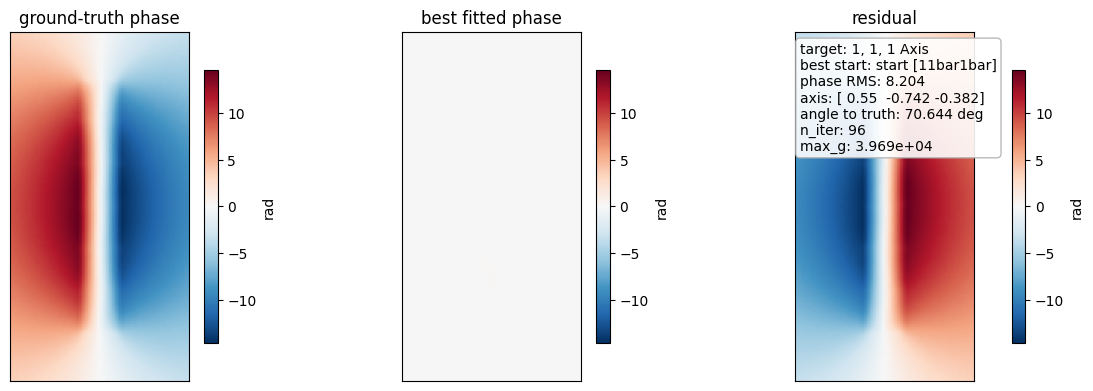

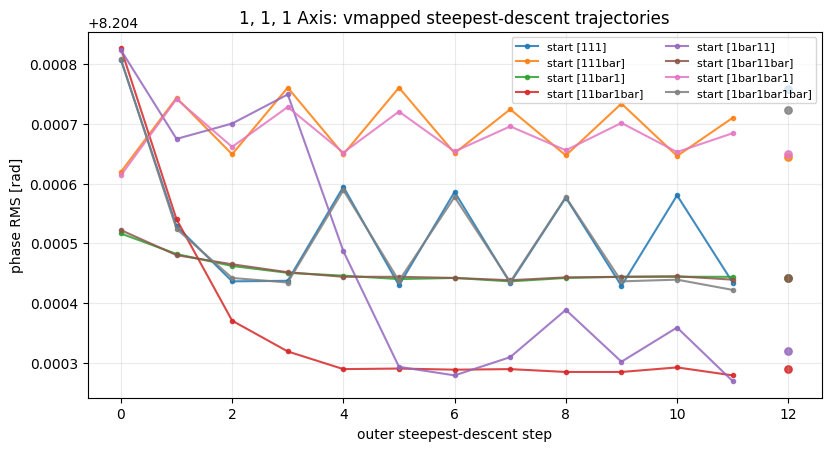

In [7]:
phase_vmax = max(
    abs(float(phase_target.min())),
    abs(float(phase_target.max())),
    abs(float(phase_pred.min())),
    abs(float(phase_pred.max())),
    1e-12,
)
residual_vmax = max(abs(float(phase_residual.min())), abs(float(phase_residual.max())), 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for ax, image, title, limit in [
    (axes[0], phase_target, "ground-truth phase", phase_vmax),
    (axes[1], phase_pred, "best fitted phase", phase_vmax),
    (axes[2], phase_residual, "residual", residual_vmax),
]:
    im = ax.imshow(image, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, label="rad")
axes[2].text(
    0.03,
    0.97,
    f"target: {fit_target_name}\n"
    f"best start: {best_result['start']}\n"
    f"phase RMS: {best_result['phase_rms']:.4g}\n"
    f"axis: {np.array2string(best_result['axis1'], precision=3)}\n"
    f"angle to truth: {angular_distance_deg(best_result['axis1'], ground_truth_axis):.3f} deg\n"
    f"n_iter: {best_result['n_iter']}\n"
    f"max_g: {best_result['max_g']:.4g}",
    transform=axes[2].transAxes,
    va="top",
    ha="left",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9, "edgecolor": "0.7"},
)
plt.show()

rms_steps = np.arange(rms_history_np.shape[1])
fig, ax = plt.subplots(figsize=(8.2, 4.4), constrained_layout=True)
for idx, start_label in enumerate(initial_axis_labels):
    ax.plot(rms_steps, rms_history_np[idx], marker="o", ms=3, alpha=0.85, label=start_label)
    ax.scatter([equilibrium_fit_config.outer_steps], [final_rms_np[idx]], s=28, alpha=0.85)
ax.set_title(f"{fit_target_name}: vmapped steepest-descent trajectories")
ax.set_xlabel("outer steepest-descent step")
ax.set_ylabel("phase RMS [rad]")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, ncol=2)
plt.show()

if pd is not None:
    display(fit_summary_display)
else:
    fit_summary_display